# MULTIPLE DISEASE PREDICTION

## Introduction

Healthcare is one of the most important fields where machine learning can assist in early disease detection and diagnosis. This project aims to develop a Multiple Disease Prediction System capable of predicting the likelihood of Diabetes, Heart Disease, and Kidney Disease using machine learning algorithms.

The system uses historical medical data, data preprocessing techniques, and classification algorithms to make predictions based on patient health parameters.

# Section 1: Diabetes Prediction

This section focuses on predicting whether a person is diabetic using health-related attributes such as glucose level, BMI, insulin level, and age.

Algorithm Used: Support Vector Machine (SVM)

## Step 1: Dataset Loading and Exploration

The diabetes dataset is loaded into a Pandas DataFrame. Basic information such as dataset dimensions, data types, statistical summary, and class distribution is examined to understand the dataset before model training.

In [ ]:
import pandas as pd
diabetes_data = pd.read_csv('diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes_data.shape

(768, 9)

In [ ]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes_data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_data['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


## Step 2: Feature and Target Selection

The target variable (Outcome) is separated from the input features. The model will learn patterns from the input features to predict diabetes.

In [ ]:
X = diabetes_data.drop(columns='Outcome', axis=1)
Y = diabetes_data['Outcome']

## Step 3: Train-Test Split and Feature Scaling

The dataset is divided into training and testing sets. Feature scaling is applied using StandardScaler to ensure that all features contribute equally during model training.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 4: Model Training

A Support Vector Machine (SVM) classifier is trained using the processed diabetes dataset.

In [ ]:
from sklearn import svm
model = svm.SVC(kernel='linear')

In [ ]:
model.fit(X_train, Y_train)

SVC(kernel='linear')

## Step 5: Model Evaluation

The trained model is evaluated using training and testing accuracy scores.

In [ ]:
from sklearn.metrics import accuracy_score
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of training data : ', training_data_accuracy)

Accuracy score of training data :  0.7866449511400652


In [ ]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of test data : ', test_data_accuracy)

Accuracy score of test data :  0.7727272727272727


In [ ]:
print("Training Accuracy :", training_data_accuracy*100)
print("Testing Accuracy :", test_data_accuracy*100)

Training Accuracy : 78.66449511400651
Testing Accuracy : 77.27272727272727


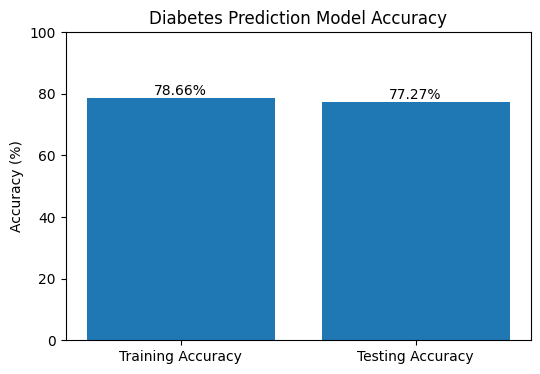

In [ ]:
import matplotlib.pyplot as plt

labels = ['Training Accuracy', 'Testing Accuracy']
accuracy = [78.66, 77.27]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracy)

plt.ylim(0,100)
plt.ylabel("Accuracy (%)")
plt.title("Diabetes Prediction Model Accuracy")

for i, value in enumerate(accuracy):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center')

plt.show()

## Step 6: Diabetes Prediction System

A sample patient's health parameters are provided to the model to predict whether the person is diabetic.

In [ ]:
import numpy as np
input_data = (5,166,72,19,175,25.8,0.587,51)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
std_data = scaler.transform(input_data_reshaped)
prediction = model.predict(std_data)
print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
if prediction[0] == 0:
    print("The person is not diabetic")
else:
    print("The person is diabetic")

The person is diabetic


# Section 2: Heart Disease Prediction

This section predicts the presence of heart disease using clinical and medical attributes obtained from the UCI Heart Disease Dataset.

### Algorithms Used
- Logistic Regression
- Random Forest

## Step 1: Dataset Loading and Exploration

The Heart Disease dataset is loaded into a Pandas DataFrame and explored to understand its structure and dimensions.


In [ ]:
import pandas as pd

column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(
    'processed.cleveland.data',
    names=column_names
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.shape

(303, 14)

## Step 2: Data Cleaning

The dataset contains missing values represented by special symbols. These missing values are identified and replaced with appropriate values using median imputation.

In [ ]:
df.replace('?', pd.NA, inplace=True)

df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df['ca'] = pd.to_numeric(df['ca'], errors='coerce')
df['thal'] = pd.to_numeric(df['thal'], errors='coerce')

df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## Step 3: Target Variable Processing

The target variable is converted into a binary classification problem:

- 0 = No Heart Disease
- 1 = Heart Disease

This simplifies the prediction task and makes it suitable for binary classification algorithms.

In [ ]:
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

In [ ]:
df['target'].value_counts()

,count
target,
0,164
1,139


## Step 4: Feature Selection and Data Splitting

The independent variables (features) and dependent variable (target) are separated. The dataset is then divided into training and testing sets for model development and evaluation.

In [ ]:
X = df.drop('target', axis=1)

Y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

## Step 5: Feature Scaling

Feature scaling is applied using StandardScaler. This ensures that all features have similar ranges and contribute equally during model training.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Step 6: Logistic Regression Model Training

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. The model is trained using the processed heart disease dataset.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, Y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score
train_prediction = model.predict(X_train)

train_accuracy = accuracy_score(
    Y_train,
    train_prediction
)

print("Training Accuracy =", train_accuracy*100)

Training Accuracy = 84.29752066115702


In [ ]:
from sklearn.metrics import accuracy_score
prediction = model.predict(X_test)

accuracy = accuracy_score(
    Y_test,
    prediction
)

print("Testing Accuracy =", accuracy*100)

Testing Accuracy = 88.52459016393442


## Step 7: Random Forest Model Training

A Random Forest classifier is trained and evaluated to compare its performance with Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, Y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    Y_test,
    rf_prediction
)

print("Random Forest Accuracy =", rf_accuracy*100)

Random Forest Accuracy = 86.88524590163934


## Step 8: Model Evaluation

The model performance is evaluated using accuracy comparison graph.

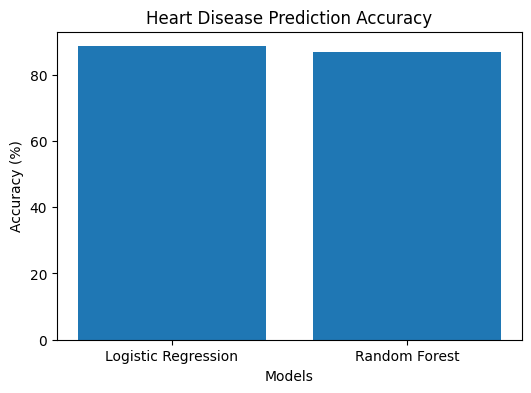

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Logistic Regression',
    'Random Forest'
]

accuracies = [
    accuracy*100,
    rf_accuracy*100
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.xlabel('Models')

plt.ylabel('Accuracy (%)')

plt.title('Heart Disease Prediction Accuracy')

plt.show()

## Step 9: Heart Disease Prediction System

A sample patient's medical information is provided to the trained model. The model predicts whether the patient is likely to have heart disease.

In [ ]:
import numpy as np

input_data = (
    63,1,3,145,233,
    1,0,150,0,
    2.3,0,0,1
)

input_data = np.asarray(input_data)

input_data = input_data.reshape(1,-1)

input_data = scaler.transform(input_data)

prediction = model.predict(input_data)

if prediction[0] == 0:
    print("No Heart Disease")
else:
    print("Heart Disease Detected")

No Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Section 3: Kidney Disease Prediction

This section predicts Chronic Kidney Disease (CKD) using patient laboratory measurements and medical indicators.

### Algorithm Used
Random Forest Classifier

## Step 1: Dataset Loading and Exploration

The Kidney Disease dataset is loaded and explored to understand its structure, dimensions, and data types.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [ ]:
kidney_data = pd.read_csv('/content/kidney_disease.csv')
kidney_data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
print(kidney_data.shape)

(400, 26)


In [ ]:
kidney_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

## Step 2: Data Cleaning and Missing Value Handling

Special characters and missing values are identified and replaced. Missing values are then handled using median and mode imputation techniques.

In [ ]:
# Replace special characters with NaN

kidney_data.replace('?', np.nan, inplace=True)
kidney_data.replace('\t?', np.nan, inplace=True)

# Clean yes/no values

kidney_data.replace('\tyes', 'yes', inplace=True)
kidney_data.replace('\tno', 'no', inplace=True)

# Check first few rows
kidney_data.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
kidney_data.isnull().sum()

,0
id,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4


In [ ]:
for col in kidney_data.columns:

    if kidney_data[col].dtype == 'object':
        kidney_data[col].fillna(
            kidney_data[col].mode()[0],
            inplace=True
        )

    else:
        kidney_data[col].fillna(
            kidney_data[col].median(),
            inplace=True
        )

/tmp/ipykernel_2149/3788447604.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kidney_data[col].fillna(
/tmp/ipykernel_2149/3788447604.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: 

In [ ]:
kidney_data.isnull().sum()

,0
id,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0


## Step 3: Label Encoding

Categorical attributes are converted into numerical values using Label Encoding so that machine learning algorithms can process them.

In [ ]:
label_encoder = LabelEncoder()

for col in kidney_data.columns:

    if kidney_data[col].dtype == 'object':
        kidney_data[col] = label_encoder.fit_transform(
            kidney_data[col]
        )

kidney_data['classification'].value_counts()

,count
classification,
0,248
2,150
1,2


## Step 4: Feature Selection and Data Splitting

The dataset is divided into input features and target labels. Training and testing datasets are then created.

In [ ]:
X = kidney_data.drop('classification', axis=1)

Y = kidney_data['classification']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,
    Y,test_size=0.2,random_state=2)

## Step 5: Model Training

A Random Forest Classifier is trained using the processed kidney disease dataset.

In [ ]:
model = RandomForestClassifier()

model.fit(X_train, Y_train)

RandomForestClassifier()

## Step 6: Model Evaluation

The model is evaluated using training accuracy, testing accuracy, and a graphical comparison of results.

In [ ]:
train_prediction = model.predict(X_train)

training_accuracy = accuracy_score(
    train_prediction,
    Y_train
)
print("Training Accuracy :", training_accuracy)

Training Accuracy : 1.0


In [ ]:
test_prediction = model.predict(X_test)
testing_accuracy = accuracy_score(
    test_prediction,
    Y_test
)
print("Testing Accuracy :", testing_accuracy)

Testing Accuracy : 0.9875


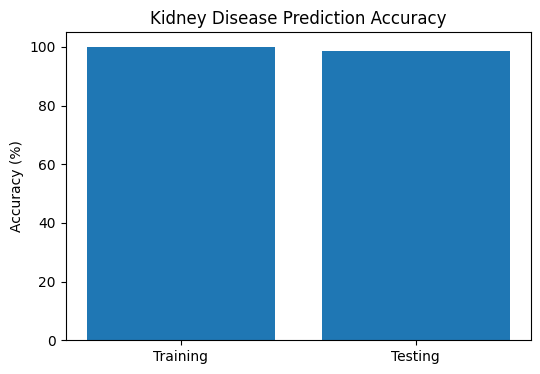

In [ ]:
accuracies = [
    training_accuracy * 100,
    testing_accuracy * 100
]

labels = [
    'Training',
    'Testing'
]

plt.figure(figsize=(6,4))

plt.bar(labels, accuracies)

plt.title("Kidney Disease Prediction Accuracy")

plt.ylabel("Accuracy (%)")

plt.show()

## Step 7: Kidney Disease Prediction System

A sample patient's health record is provided to the trained model. The model predicts whether the patient has Chronic Kidney Disease.

In [ ]:
input_data = tuple(X.iloc[50])

input_data_np = np.asarray(input_data)

input_data_reshaped = input_data_np.reshape(1,-1)

prediction = model.predict(
    input_data_reshaped
)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
if prediction[0] == 0:
    print("Person has Kidney Disease")
else:
    print("Person does not have Kidney Disease")

Person has Kidney Disease


# Section 4: Accuracy Comparison

The performance of all disease prediction models is compared using testing accuracy.

| Disease | Algorithm | Testing Accuracy (%) |
|----------|------------|----------|
| Diabetes | SVM | 77.27 |
| Heart Disease | Logistic Regression | 88.52 |
| Kidney Disease | Random Forest | 98.75 |

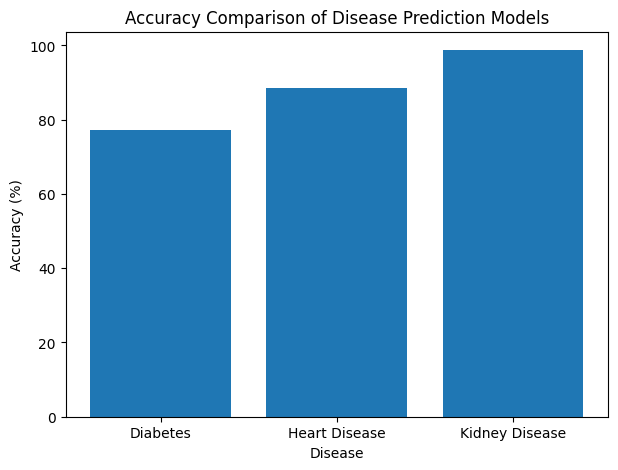

In [ ]:
import matplotlib.pyplot as plt

diseases = [
    'Diabetes',
    'Heart Disease',
    'Kidney Disease'
]

accuracies = [
    77.27,
    88.52,
    98.75
]

plt.figure(figsize=(7,5))

plt.bar(diseases, accuracies)

plt.xlabel('Disease')

plt.ylabel('Accuracy (%)')

plt.title('Accuracy Comparison of Disease Prediction Models')

plt.show()

# Section 5: Conclusion

This project successfully developed a Multiple Disease Prediction System using Machine Learning techniques.

Three separate disease prediction models were developed:

- Diabetes Prediction using Support Vector Machine (SVM)
- Heart Disease Prediction using Logistic Regression and Random Forest
- Kidney Disease Prediction using Random Forest Classifier

The datasets were collected, cleaned, and preprocessed before training the models. The obtained testing accuracies were:

- Diabetes Prediction: 77.27%
- Heart Disease Prediction: 88.52%
- Kidney Disease Prediction: 98.75%

The results demonstrate the effectiveness of machine learning techniques in healthcare applications and their potential for supporting early disease detection and medical decision-making.